[Module 2 Homework](https://colab.research.google.com/github/Jaguar838/stock-markets-analytics-zoomcamp/blob/main/HW/2025/hw-02/hw-02.ipynb)

In [1]:
# IMPORTS
import pandas as pd
import requests
from io import StringIO

#Fin Data Sources
import yfinance as yf

#Data viz
import plotly.graph_objs as go
import plotly.express as px

import matplotlib.pyplot as plt
import seaborn as sns

import time
from datetime import date, timedelta
from functools import wraps


def normalize_column_names(df):
    """
    Приводить назви колонок до нижнього регістру та замінює пробіли/дефіси на підкреслення.
    """
    df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')
    return df


def clean_and_convert_column(df, column_name):
    """
    Очищає значення в зазначеній колонці DataFrame від небажаних символів
    і перетворює їх у числовий формат.
    """
    df = df.copy()  # додано для уникнення SettingWithCopyWarning
    df[column_name] = (
        df[column_name]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('$', '', regex=False)
        .str.strip()
    )
    df[column_name] = pd.to_numeric(df[column_name], errors='coerce')
    return df


def handle_errors(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        try:
            return func(*args, **kwargs)
        except requests.exceptions.RequestException as e:
            print(f"Request failed: {e}")
        except ValueError as ve:
            print(f"Data error: {ve}")
        except Exception as ex:
            print(f"Unexpected error: {ex}")
        return pd.DataFrame()
    return wrapper


### Question 1: [IPO] Withdrawn IPOs by Company Type

**Яка загальна сума виведених коштів з ІРО (у мільйонах доларів США) для класу компаній з найбільшою загальною сумою виведених коштів?**

Зі списку відкликаних IPO ([stockanalysis.com/ipos/withdrawn](https://stockanalysis.com/ipos/withdrawn/)) зберіть та обробіть дані, щоб з'ясувати, який тип компаній отримав найбільше відкликаних IPO.

Крок за кроком:
1. Використовуйте `pandas.read_html()` з наведеною вище URL-адресою, щоб завантажити таблицю виведення IPO в DataFrame.
   *Процес аналогічний до фрагменту коду 1, що обговорюється в прямому ефірі.* Ви маєте отримати **99 записів**.
2. Створіть новий стовпець під назвою `Company Class`, класифікуючи назви компаній за такими шаблонами, як:
   - "Acquisition Corp." або "Acquisition Corporation" → `Acq.Corp`.
   - "Inc." або "Incorporated" → `Inc`.
   - "Group" або "Group" → `Group`
   - "Ltd." або "Limited" → `Limited`, "Обмежений" → `Limited`.
   - "Holdings" → `Holdings`.
   - "Others" → `Other`.

  * Порядок: Будь ласка, дотримуйтесь переліченого порядку класів і присвоюйте перше знайдене значення (наприклад, для "shenni holdings limited" ви присвоюєте клас "Limited").

  * Підказка: зробіть вашу функцію більш надійною, перетворивши імена в малі літери та розбивши їх на слова перед тим, як порівнювати шаблони.

3. Визначте нове поле `Avg. Price` шляхом аналізу поля `Price Range` (створіть функцію і застосуйте її до стовпця `Price Range`).
  Приклади:
   - `$8.00 - $10.00` → `9.0`
   - `$5.00` → `5.0`
   - '-' → `None`

4. Перетворіть `Shares Offered` в числові, очистіть відсутні або недійсні значення.
5. Створіть новий стовпець:  
   `Withdrawn Value = Shares Offered * Avg Price` (**71 non-null values**)
6. Згрупуйте за "Класом компанії" та підрахуйте загальну вилучену вартість.
7. **Answer**: Який клас має найбільшу **total** вартість виведених коштів?
---

In [2]:
@handle_errors
def get_ipos(url: str) -> pd.DataFrame:
    """
    Завантажує IPO-таблицю з заданого URL (stockanalysis.com),
    нормалізує назви колонок, перетворює дати, сортує по даті.
    """
    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/58.0.3029.110 Safari/537.3'
        )
    }

    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()

    html_io = StringIO(response.text)
    tables = pd.read_html(html_io)

    if not tables:
        raise ValueError("No tables found at provided URL.")

    df = tables[0]
    df = normalize_column_names(df)

    # Перетворення всіх колонок із "date" у назві в datetime
    for col in df.columns:
        if 'date' in col:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # Сортуємо по першій колонці, яка є датою
    date_cols = [col for col in df.columns if 'date' in col]
    if date_cols:
        df = df.sort_values(by=date_cols[0], ascending=False)

    return df

In [3]:
# Парсимо таблицю з IPO:
url = "https://stockanalysis.com/ipos/withdrawn/"
df_withdrawn_ipos =get_ipos(url)

df_withdrawn_ipos.head(10)

,symbol,company_name,price_range,shares_offered
0,ODTX,"Odyssey Therapeutics, Inc.",-,-
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000
2,AURN,"Aurion Biotech, Inc.",-,-
3,ROTR,"PHI Group, Inc.",-,-
4,ONE,One Power Company,-,-
5,HPOT,The Great Restaurant Development Holdings Limited,$4.00 - $6.00,1400000
6,CABR,"Caring Brands, Inc.",$4.00,750000
7,SQVI,"Sequoia Vaccines, Inc.",$8.00 - $10.00,2775000
8,SNI,Shenni Holdings Limited,$4.00 - $6.00,3000000
9,KMCM,Key Mining Corp.,$2.25,4444444


In [4]:
df_withdrawn_ipos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   symbol          100 non-null    object
 1   company_name    100 non-null    object
 2   price_range     100 non-null    object
 3   shares_offered  100 non-null    object
dtypes: object(4)
memory usage: 3.3+ KB


In [5]:
def classify_company(name):
    name = name.lower()
    words = name.split()

    if 'acquisition' in words and ('corp.' in words or 'corp' in words or 'corporation' in words):
        return 'Acq.Corp.'
    elif 'inc.' in words or 'incorporated' in words:
        return 'Inc.'
    elif 'group' in words:
        return 'Group'
    elif 'ltd.' in words or 'limited' in words:
        return 'Limited'
    elif 'holdings' in words:
        return 'Holdings'
    else:
        return 'Other'


# Застосовуємо функцію до кожного рядка
df_withdrawn_ipos['company_class'] = df_withdrawn_ipos.company_name.apply(classify_company)

df_withdrawn_ipos.head(10)

,symbol,company_name,price_range,shares_offered,company_class
0,ODTX,"Odyssey Therapeutics, Inc.",-,-,Inc.
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000,Inc.
2,AURN,"Aurion Biotech, Inc.",-,-,Inc.
3,ROTR,"PHI Group, Inc.",-,-,Inc.
4,ONE,One Power Company,-,-,Other
5,HPOT,The Great Restaurant Development Holdings Limited,$4.00 - $6.00,1400000,Limited
6,CABR,"Caring Brands, Inc.",$4.00,750000,Inc.
7,SQVI,"Sequoia Vaccines, Inc.",$8.00 - $10.00,2775000,Inc.
8,SNI,Shenni Holdings Limited,$4.00 - $6.00,3000000,Limited
9,KMCM,Key Mining Corp.,$2.25,4444444,Other


In [6]:
def parse_avg_price(price_range):
    if not isinstance(price_range, str) or price_range.strip() == '-' or price_range.strip() == '':
        return None

    # Прибираємо символи долара і пробіли
    cleaned = price_range.replace('$', '').strip()

    # Розбиваємо за тире
    parts = cleaned.split('-')

    try:
        # Якщо два числа — беремо середнє
        if len(parts) == 2:
            low = float(parts[0].strip())
            high = float(parts[1].strip())
            return round((low + high) / 2, 2)
        # Якщо одне число — просто повертаємо
        elif len(parts) == 1:
            return round(float(parts[0].strip()), 2)
        else:
            return None
    except ValueError:
        return None


df_withdrawn_ipos['avg_price'] = df_withdrawn_ipos.price_range.apply(parse_avg_price)

df_withdrawn_ipos.head(10)

,symbol,company_name,price_range,shares_offered,company_class,avg_price
0,ODTX,"Odyssey Therapeutics, Inc.",-,-,Inc.,NaN
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000,Inc.,3.50
2,AURN,"Aurion Biotech, Inc.",-,-,Inc.,NaN
3,ROTR,"PHI Group, Inc.",-,-,Inc.,NaN
4,ONE,One Power Company,-,-,Other,NaN
5,HPOT,The Great Restaurant Development Holdings Limited,$4.00 - $6.00,1400000,Limited,5.00
6,CABR,"Caring Brands, Inc.",$4.00,750000,Inc.,4.00
7,SQVI,"Sequoia Vaccines, Inc.",$8.00 - $10.00,2775000,Inc.,9.00
8,SNI,Shenni Holdings Limited,$4.00 - $6.00,3000000,Limited,5.00
9,KMCM,Key Mining Corp.,$2.25,4444444,Other,2.25


In [7]:
# Видалимо коми, пробіли, символи типу '$', і спробуємо перетворити в число
df_withdrawn_ipos = clean_and_convert_column(df_withdrawn_ipos, 'shares_offered')


df_withdrawn_ipos.head(10)

,symbol,company_name,price_range,shares_offered,company_class,avg_price
0,ODTX,"Odyssey Therapeutics, Inc.",-,NaN,Inc.,NaN
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000.0,Inc.,3.50
2,AURN,"Aurion Biotech, Inc.",-,NaN,Inc.,NaN
3,ROTR,"PHI Group, Inc.",-,NaN,Inc.,NaN
4,ONE,One Power Company,-,NaN,Other,NaN
5,HPOT,The Great Restaurant Development Holdings Limited,$4.00 - $6.00,1400000.0,Limited,5.00
6,CABR,"Caring Brands, Inc.",$4.00,750000.0,Inc.,4.00
7,SQVI,"Sequoia Vaccines, Inc.",$8.00 - $10.00,2775000.0,Inc.,9.00
8,SNI,Shenni Holdings Limited,$4.00 - $6.00,3000000.0,Limited,5.00
9,KMCM,Key Mining Corp.,$2.25,4444444.0,Other,2.25


In [8]:
df_withdrawn_ipos['withdrawn_value'] = df_withdrawn_ipos.shares_offered * df_withdrawn_ipos.avg_price

df_withdrawn_ipos.head(10)

,symbol,company_name,price_range,shares_offered,company_class,avg_price,withdrawn_value
0,ODTX,"Odyssey Therapeutics, Inc.",-,NaN,Inc.,NaN,NaN
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000.0,Inc.,3.50,7000000.0
2,AURN,"Aurion Biotech, Inc.",-,NaN,Inc.,NaN,NaN
3,ROTR,"PHI Group, Inc.",-,NaN,Inc.,NaN,NaN
4,ONE,One Power Company,-,NaN,Other,NaN,NaN
5,HPOT,The Great Restaurant Development Holdings Limited,$4.00 - $6.00,1400000.0,Limited,5.00,7000000.0
6,CABR,"Caring Brands, Inc.",$4.00,750000.0,Inc.,4.00,3000000.0
7,SQVI,"Sequoia Vaccines, Inc.",$8.00 - $10.00,2775000.0,Inc.,9.00,24975000.0
8,SNI,Shenni Holdings Limited,$4.00 - $6.00,3000000.0,Limited,5.00,15000000.0
9,KMCM,Key Mining Corp.,$2.25,4444444.0,Other,2.25,9999999.0


In [9]:
grouped_df = df_withdrawn_ipos.groupby('company_class')['withdrawn_value'].sum().sort_values(ascending=False)
len(grouped_df)

6

In [10]:
grouped_df = grouped_df.reset_index()
grouped_df.columns = ['company_class', 'withdrawn_value']
grouped_df.head(6)


,company_class,withdrawn_value
0,Acq.Corp.,4.021000e+09
1,Inc.,2.257164e+09
2,Other,7.741700e+08
3,Limited,5.434846e+08
4,Holdings,7.500000e+07
5,Group,3.378750e+07


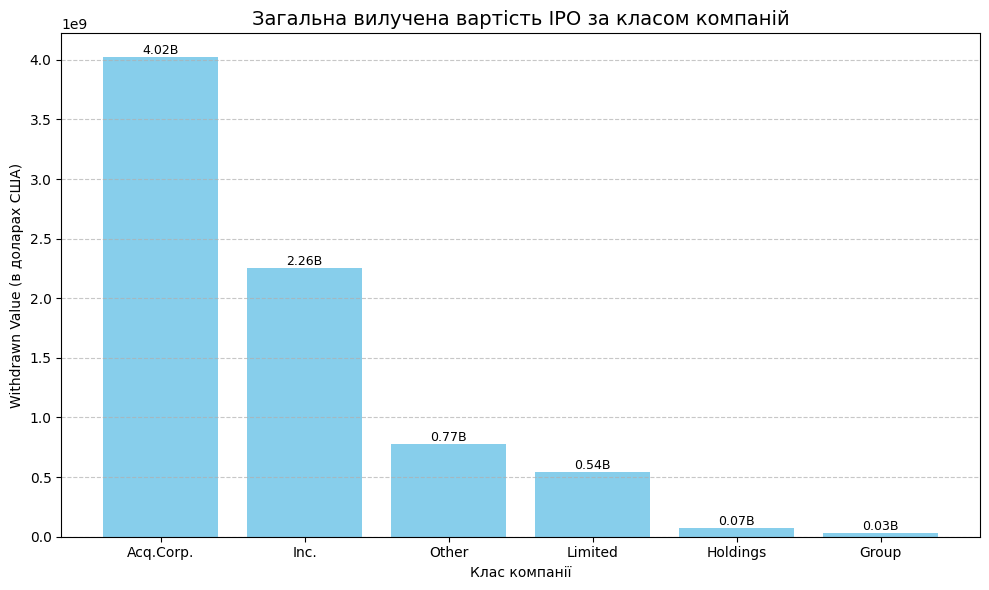

In [11]:
# Побудова стовпчикової діаграми
plt.figure(figsize=(10, 6))
bars = plt.bar(grouped_df['company_class'], grouped_df['withdrawn_value'], color='skyblue')

# Підписи значень над стовпчиками
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height/1e9:.2f}B',
             ha='center', va='bottom', fontsize=9)

plt.title('Загальна вилучена вартість IPO за класом компаній', fontsize=14)
plt.xlabel('Клас компанії')
plt.ylabel('Withdrawn Value (в доларах США)')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [12]:
print(
    f'Answer: Клас компаній з найбільшою загальною вартістю виведених коштів — {grouped_df.company_class[0]}, із сумою ${grouped_df.withdrawn_value[0]/1e9:.2f} млрд.'
    )

Answer: Клас компаній з найбільшою загальною вартістю виведених коштів — Acq.Corp., із сумою $4.02 млрд.


### Question 2:   [IPO] Median Sharpe Ratio for 2024 IPOs (First 5 Months)

**Яким є медіанний коефіцієнт Шарпа (станом на 6 червня 2025 року) для компаній, які стали публічними за перші 5 місяців 2024 року?**

Мета полягає в тому, щоб відтворити великомасштабне завантаження даних "yfinance" OHLCV і виконати базові фінансові розрахунки щодо акцій IPO.

1. Використовуючи той самий підхід, що і в питанні 1, завантажте IPO у 2024 році з:
 [https://stockanalysis.com/ipos/2024/](https://stockanalysis.com/ipos/2024/)
 Відфільтруйте, щоб залишити лише ті IPO, які відбулися **до 1 червня 2024 року** (перші 5 місяців 2024 року).  
   У вас повинно бути **75 тикерів**.

2.  Використовуйте **Фрагмент коду 7**, щоб завантажити щоденні дані про запаси для цих тикерів (через `yfinance`).  
   Переконайтеся, що ви розумієте, як визначаються стовпці `growth_1d` ... `growth_365d` та стовпці волатильності.  
   Визначте новий стовпець `growth_252d`, що відображає зростання після **252 торгових днів** (~1 рік), на додаток до будь-яких інших періодів зростання, які ви вже відстежуєте.

3. Розрахуйте коефіцієнт Шарпа, припускаючи, що безризикова ставка становить **4.5%**:

   ```python
 stocks_df['Sharpe'] = (stocks_df['growth_252d'] - 0.045) / stocks_df['volatility']
 ```

   ⚠️ **IMPORTANT:**  Пожалуйста, используйте оригинальную версию расчета годовой волатильности (позже она была исправлена на другую формулу):

  ```python
 stocks_df['volatility'] = stocks_df['Close'].rolling(30).std() * np.sqrt(252)
 ```

4. Відфільтруйте DataFrame, щоб зберегти дані тільки за торговий день:
   **'2025-06-06'**

   Обчисліть описову статистику (наприклад, `.describe()`) для цих стовпців:
   - `growth_252d`
   - `Sharpe`

   Ви повинні спостерігати:
   - `growth_252d` визначено для **71 з 75 акцій** (деякі IPO є занадто пізніми або дані починаються пізніше).
   - Медіана `growth_252d` становить приблизно **0,75** (що вказує на 25% падіння), тоді як середнє значення становить приблизно **1.15**, що свідчить про те, що компанії, які швидко зростають, підштовхують середнє значення вгору.

5. **Answer:**
   - Який **середній коефіцієнт Шарпа** для цих 71 акцій?
   - Примітка: Позитивне значення показника Шарпа означає зростання, що перевищує безризикову ставку 4,5%.
   - [Additional] Чи спостерігаєте ви **однакові 10 найкращих компаній** при сортуванні за `growth_252d` та сортуванні за `Sharpe`?

In [13]:
# Парсимо таблицю з IPO:
url = "https://stockanalysis.com/ipos/2024/"
df_2024_ipos =get_ipos(url)

df_2024_ipos.head(10)

,ipo_date,symbol,company_name,ipo_price,current,return
0,2024-12-31,ONEG,OneConstruction Group Limited,$4.00,$5.00,25.00%
1,2024-12-27,PHH,"Park Ha Biological Technology Co., Ltd.",$4.00,$26.57,564.25%
2,2024-12-23,HIT,"Health In Tech, Inc.",$4.00,$0.62,-84.40%
3,2024-12-23,TDAC,Translational Development Acquisition Corp.,$10.00,$10.28,2.80%
4,2024-12-20,RANG,Range Capital Acquisition Corp.,$10.00,$10.21,2.10%
5,2024-12-20,YAAS,Youxin Technology Ltd,$4.50,$3.03,-32.67%
6,2024-12-19,LSE,"Leishen Energy Holding Co., Ltd.",$4.00,$6.05,51.25%
7,2024-12-18,NCEW,New Century Logistics (BVI) Limited,$4.00,$0.99,-75.37%
8,2024-12-18,YSXT,"YSX Tech. Co., Ltd",$4.00,$5.62,40.50%
9,2024-12-13,AVR,Anteris Technologies Global Corp.,$6.00,$4.04,-32.67%


In [14]:
df_2024_ipos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 225 entries, 0 to 224
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ipo_date      225 non-null    datetime64[ns]
 1   symbol        225 non-null    object        
 2   company_name  225 non-null    object        
 3   ipo_price     225 non-null    object        
 4   current       225 non-null    object        
 5   return        225 non-null    object        
dtypes: datetime64[ns](1), object(5)
memory usage: 12.3+ KB


In [15]:
# Встановлюємо дату-фільтр
cutoff_date = pd.Timestamp("2024-06-01")

# Фільтруємо IPO до 1 червня 2024 року
filtered_df = df_2024_ipos[df_2024_ipos['ipo_date'] < cutoff_date]
df_June_ipos = clean_and_convert_column(filtered_df, 'ipo_price')

# Фільтруємо тільки ті рядки, де ipo_price не є NaN
filtered_with_price = df_June_ipos[df_June_ipos['ipo_price'].notna()]

# Отримуємо список тікерів
tickers = filtered_with_price['symbol'].tolist()

# Перевіримо кількість результатів і виведемо перші рядки
print(f"Кількість IPO до 1 червня 2024 року: {len(tickers)}")
filtered_with_price.head()

Кількість IPO до 1 червня 2024 року: 75


,ipo_date,symbol,company_name,ipo_price,current,return
149,2024-05-23,BOW,Bowhead Specialty Holdings Inc.,17.00,$36.49,114.65%
150,2024-05-17,HDL,Super Hi International Holding Ltd.,19.56,$18.70,-4.40%
151,2024-05-17,RFAI,RF Acquisition Corp II,10.00,$10.60,6.00%
153,2024-05-15,RAY,Raytech Holding Limited,4.00,$1.23,-69.25%
152,2024-05-15,JDZG,JIADE Limited,4.00,$0.26,-93.40%


In [ ]:
import numpy as np


# Ініціалізація порожнього DataFrame
stocks_df = pd.DataFrame()

# Обхід по кожному тікеру
for i, ticker in enumerate(tickers):
    print(f"{i+1}/{len(tickers)} - {ticker}")

    try:
        # Завантаження історичних цін
        ticker_obj = yf.Ticker(ticker)
        historyPrices = ticker_obj.history(period="max", interval="1d")

        # Якщо немає даних — пропускаємо
        if historyPrices.empty:
            print(f"⛔ Немає даних для {ticker}")
            continue

        # Базові ознаки
        historyPrices['Ticker'] = ticker
        historyPrices['Year'] = historyPrices.index.year
        historyPrices['Month'] = historyPrices.index.month
        historyPrices['Weekday'] = historyPrices.index.weekday
        historyPrices['Date'] = historyPrices.index.date

        # Розрахунок доходностей
        for days in [1, 3, 7, 30, 90, 252]:
            historyPrices[f'growth_{days}d'] = historyPrices['Close'] / historyPrices['Close'].shift(days)

        # Технічні індикатори
        historyPrices['SMA10'] = historyPrices['Close'].rolling(10).mean()
        historyPrices['SMA20'] = historyPrices['Close'].rolling(20).mean()
        historyPrices['growing_moving_average'] = np.where(historyPrices['SMA10'] > historyPrices['SMA20'], 1, 0)
        historyPrices['high_minus_low_relative'] = (historyPrices['High'] - historyPrices['Low']) / historyPrices['Close']

        historyPrices['volatility'] = historyPrices['Close'].rolling(30).std() * np.sqrt(252)
        historyPrices['sharpe'] = (historyPrices['growth_252d'] - 0.045) / historyPrices['volatility']

        # Додаємо в загальний DataFrame
        stocks_df = pd.concat([stocks_df, historyPrices], ignore_index=True)

        # Пауза для API
        time.sleep(1)

    except Exception as e:
        print(f"⚠️ Помилка з {ticker}: {e}")
        continue

In [27]:
stocks_df.to_csv('stocks.csv')
stocks_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,Year,Month,...,growth_7d,growth_30d,growth_90d,growth_252d,SMA10,SMA20,growing_moving_average,high_minus_low_relative,volatility,sharpe
0,23.000000,24.270000,22.139999,23.799999,3335800,0.0,0.0,BOW,2024,5,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0.089496,NaN,NaN
1,24.260000,26.150000,23.980000,25.700001,990500,0.0,0.0,BOW,2024,5,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0.084436,NaN,NaN
2,25.850000,26.879999,25.075001,26.480000,555100,0.0,0.0,BOW,2024,5,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0.068165,NaN,NaN
3,26.440001,26.490000,25.500999,26.290001,302700,0.0,0.0,BOW,2024,5,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0.037619,NaN,NaN
4,27.209999,27.209999,25.500000,26.139999,200900,0.0,0.0,BOW,2024,5,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0.065417,NaN,NaN


In [28]:
filtered_day_df = stocks_df[stocks_df['Date'] == pd.to_datetime('2025-06-06').date()]
stats = filtered_day_df[['growth_252d', 'sharpe']].describe()
stats

,growth_252d,sharpe
count,71.000000,71.000000
mean,1.152897,0.288285
std,1.406017,0.519028
min,0.024970,-0.079677
25%,0.293422,0.041215
50%,0.758065,0.083768
75%,1.362736,0.311507
max,8.097413,2.835668


In [33]:
# Топ-10 компаній за growth_252d
top_growth = filtered_day_df.sort_values(by='growth_252d', ascending=False).head(10)['Ticker']

# Топ-10 компаній за Sharpe
top_sharpe = filtered_day_df.sort_values(by='sharpe', ascending=False).head(10)['Ticker']

common_tickers = set(top_growth) & set(top_sharpe)

print(f"Спільні тікери в обох топ-10: {list(common_tickers)}")
print(f"Кількість спільних компаній: {len(common_tickers)} з 10")
top_sharpe


Спільні тікери в обох топ-10: ['JL']
Кількість спільних компаній: 1 з 10


,Ticker
10893,BKHA
21159,JVSA
16989,LEGT
10304,IBAC
14632,HLXB
8180,MNDR
13617,DYCQ
12146,INTJ
20485,JL
5816,TRSG


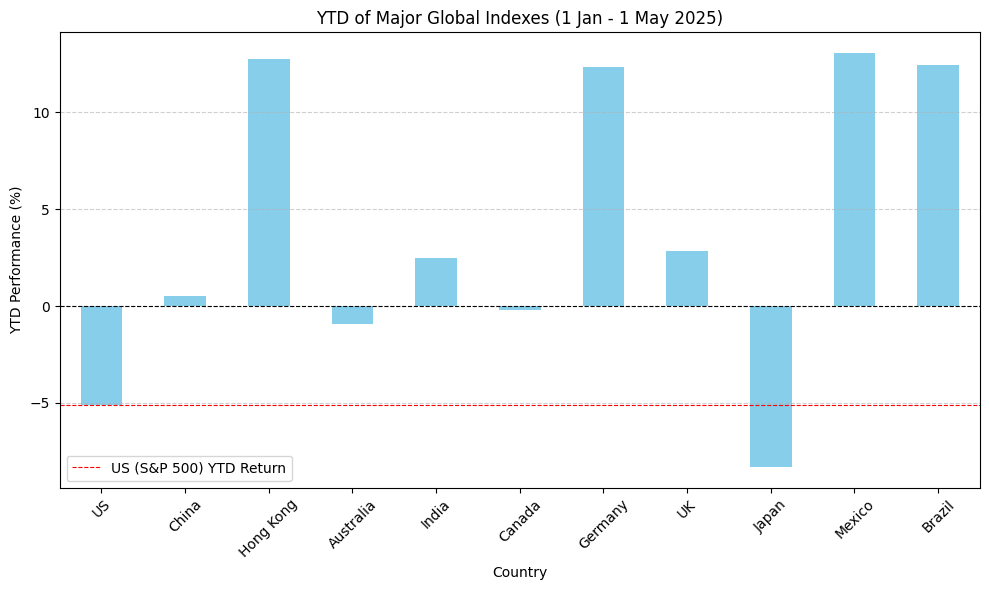

In [ ]:
# plot the YTD returns per country
plt.figure(figsize=(10, 6))
country_df = pd.Series(country_ytd)
country_df.plot(kind='bar', color='skyblue')

plt.axhline(y=US_ytd, color='red', linewidth=0.8, linestyle='--',
            label='US (S&P 500) YTD Return')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('YTD of Major Global Indexes (1 Jan - 1 May 2025)')
plt.xlabel('Country')
plt.ylabel('YTD Performance (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

*Additional*: Скільки з цих індексів мають кращу доходність, ніж S&P 500 за 3, 5 та 10 років? Чи бачите ви таку ж тенденцію?

Note: Для спрощення ігноруємо ефекти конвертації валют.

In [ ]:
# Define target periods
date_offsets = {
    "3Y": pd.to_datetime("2021-12-31"),
    "5Y": pd.to_datetime("2019-12-31"),
    "10Y": pd.to_datetime("2014-12-31")
}
end_date = pd.to_datetime("2025-01-01")
date_offsets

{'3Y': Timestamp('2021-12-31 00:00:00'),
 '5Y': Timestamp('2019-12-31 00:00:00'),
 '10Y': Timestamp('2014-12-31 00:00:00')}

In [ ]:
# Store results
results = []

for country, symbol in tickers.items():
    data = {'Country': country}
    try:
        # Download data (with small buffer around the 10-year mark)
        ticker = yf.Ticker(symbol)
        hist = ticker.history(
            start=date_offsets["10Y"] - timedelta(days=1),
            end=end_date + timedelta(days=1),
            interval='1d'
        )
        # print(hist)
        # Use naive datetime (remove timezone if present)
        hist.index = hist.index.tz_localize(None)
        hist = hist[['Close']].dropna()

        # Get latest price up to Jan 1, 2025
        price_today = hist[hist.index <= end_date].iloc[-1]['Close']

        # Get returns for each period
        for label, date in date_offsets.items():
            past_price = hist[hist.index <= date].iloc[-1]['Close']
            data[f'{label}TD'] = (price_today / past_price - 1) * 100
    except Exception as e:
        print(f"Error with {symbol}: {e}")
        data[f'3YTD'] = data[f'5YTD'] = data[f'10YTD'] = None
    results.append(data)

In [ ]:
# Convert to DataFrame
returns_df = pd.DataFrame(results)
returns_df

,Country,3YTD,5YTD,10YTD
0,US,23.403431,82.049840,185.668569
1,China,-7.913036,9.889398,3.619710
2,Hong Kong,-14.265184,-28.839563,-15.018360
3,Australia,9.597561,22.067294,50.787287
4,India,36.814745,95.118524,186.656523
5,Canada,16.515726,44.917776,68.994148
6,Germany,25.334061,50.268895,103.039514
7,UK,10.677771,8.360735,24.472668
8,Japan,38.562585,68.640070,128.611919
9,Mexico,-7.056504,13.716376,14.758401


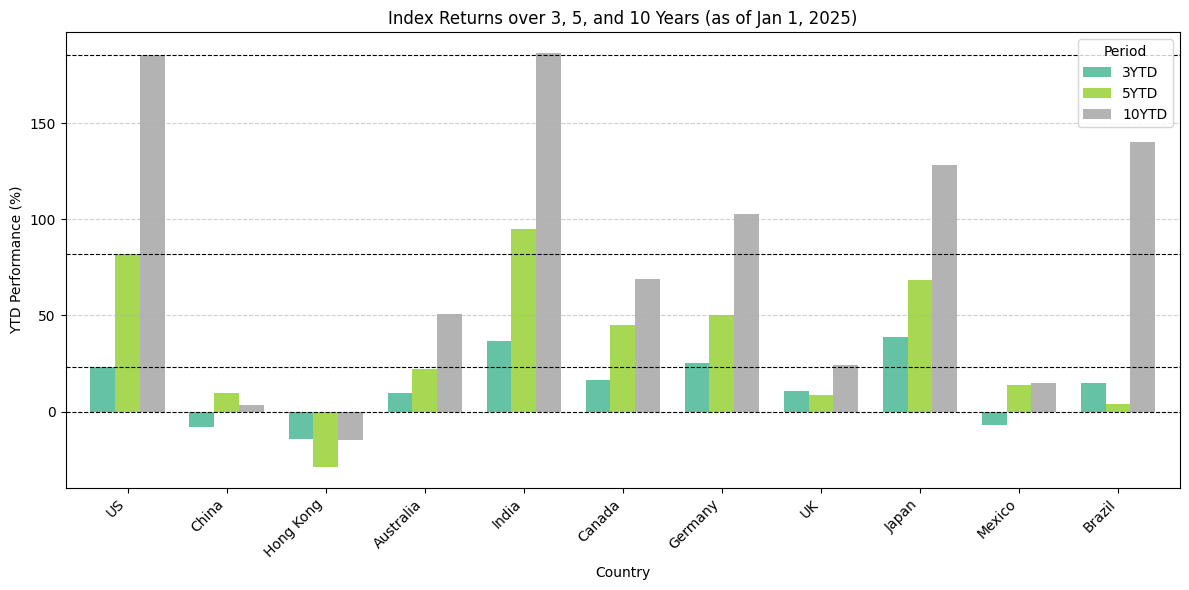

In [ ]:
# Set index names for x-axis labels
returns_df_plot = returns_df.set_index('Country')

# Plot setup
fig, ax = plt.subplots(figsize=(12, 6))
returns_df_plot[['3YTD', '5YTD', '10YTD']].plot(
    kind='bar',
    ax=ax,
    width=0.75,
    colormap='Set2'
)

# Titles and labels
plt.title("Index Returns over 3, 5, and 10 Years (as of Jan 1, 2025)")
plt.ylabel("YTD Performance (%)")
plt.xlabel("Country")

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axhline(y=23.4, color='black', linewidth=0.8, linestyle='--')
plt.axhline(y=82.04, color='black', linewidth=0.8, linestyle='--')
plt.axhline(y=185.66, color='black', linewidth=0.8, linestyle='--')

plt.xticks(rotation=45, ha='right')
plt.legend(title="Period")
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.show()

---
### Question 3: [IPO] ‘Fixed Months Holding Strategy’

**Яка оптимальна кількість місяців (від 1 до 12) для утримання акцій, щойно випущених на IPO, з метою максимізації середнього зростання?
(*Припустимо, що ви купуєте на закритті першого торгового дня і продаєте через фіксовану кількість торгових днів.*)

---

#### Мета:
Дослідити, чи утримання акцій IPO протягом фіксованої кількості місяців після першого торгового дня приносить кращі прибутки, використовуючи стовпчики майбутнього зростання.

---

#### Steps:

1. **Start from the existing DataFrame** from Question 2 (75 tickers from IPOs in the first 5 months of 2024).  

   Add **12 new columns**:  
   `future_growth_1m`, `future_growth_2m`, ..., `future_growth_12m`  
   *(Assume 1 month = 21 trading days, so growth is calculated over 21, 42, ..., 252 trading days)*  
   This logic is similar to `historyPrices['growth_future_30d']` from **Code Snippet 7**, but extended to longer timeframes.

2. **Determine the first trading day** (`min_date`) for each ticker.  
   This is the earliest date in the data for each stock.

3. **Join the data**:  
   Perform an **inner join** between the `min_date` DataFrame and the future growth data on both `ticker` and `date`.  
   ➤ You should end up with **75 records** (one per IPO) with all 12 `future_growth_...` fields populated.

4. **Compute descriptive statistics** for the resulting DataFrame:  
   Use `.describe()` or similar to analyze each of the 12 columns:  
   - `future_growth_1m`  
   - `future_growth_2m`  
   - ...  
   - `future_growth_12m`  

5. **Determine the best holding period**:  
   - Find the number of months **(1 to 12)** where the **average (mean)** future growth is **maximal**.  
   - This optimal month shows an uplift of **>1%** compared to all others.  
   - Still, the average return remains **less than 1** (i.e., expected return is less than doubling your investment).


---

In [ ]:
# Завантаження щоденних даних для S&P 500 за діапазон дат
sp500_daily = yf.download(tickers = "^GSPC",
                          start = "1950-01-01",
                          end = "2025-05-01",
                          interval = "1d")['Close']

sp500_daily = sp500_daily.reset_index()
sp500_daily.columns = ["date", "close"]
sp500_daily.head()

[*********************100%***********************]  1 of 1 completed


,date,close
0,1950-01-03,16.66
1,1950-01-04,16.85
2,1950-01-05,16.93
3,1950-01-06,16.98
4,1950-01-09,17.08


In [ ]:
sp500_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18952 entries, 0 to 18951
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    18952 non-null  datetime64[ns]
 1   close   18952 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 296.3 KB


In [ ]:
# All time high points(ATH):
sp500_daily['ATH'] = sp500_daily.close.cummax()
high_points = sp500_daily[sp500_daily.close == sp500_daily['ATH']].copy().reset_index()
high_points.head(10)

,index,date,close,ATH
0,0,1950-01-03,16.660000,16.660000
1,1,1950-01-04,16.850000,16.850000
2,2,1950-01-05,16.930000,16.930000
3,3,1950-01-06,16.980000,16.980000
4,4,1950-01-09,17.080000,17.080000
5,6,1950-01-11,17.090000,17.090000
6,22,1950-02-02,17.230000,17.230000
7,23,1950-02-03,17.290001,17.290001
8,24,1950-02-06,17.320000,17.320000
9,42,1950-03-06,17.320000,17.320000


In [ ]:
# Знайдемо мінімальні значення між кожною парою ATH
min_between_highs = []

for i in range(len(high_points) - 1):
    start_idx = high_points.loc[i, 'index']
    end_idx = high_points.loc[i+1, 'index']

    # print(start_idx, end_idx)
    if end_idx - start_idx > 1:
        between = sp500_daily.loc[start_idx + 1:end_idx - 1]
        min_row = between.loc[between.close.idxmin()]

        min_between_highs.append({
            'from_date': sp500_daily.loc[start_idx, 'date'],
            'to_date': min_row.date,
            'high_price': sp500_daily.loc[start_idx, 'close'],
            'min_price': min_row.close,
            'min_date': min_row.date
        })

# Перетворимо у DataFrame
min_df = pd.DataFrame(min_between_highs)
# min_df.head()

# Обчислимо drawdown у відсотках
min_df['drawdown%'] = (min_df['high_price'] - min_df['min_price']) / min_df['high_price'] * 100

# Відфільтруємо лише ті, що мають drawdown >= 5%
corrections = min_df[min_df['drawdown%'] >= 5].copy()

# Обчислимо тривалість drawdown у днях
corrections['durations_days'] = (corrections['to_date'] - corrections['from_date']).dt.days

# Обчислимо квартилі тривалості drawdown
percentiles = corrections['durations_days'].quantile([0.25, 0.5, 0.75]).to_dict()

# Топ-10 найбільших drawdown
top_drawdowns = corrections.sort_values(by='drawdown%', ascending=False).head(10)

# Виведемо основні результати
print(top_drawdowns[['from_date', 'to_date', 'drawdown%', 'durations_days']])


     from_date    to_date  drawdown%  durations_days
448 2007-10-09 2009-03-09  56.775388             517
443 2000-03-24 2002-10-09  49.146948             929
206 1973-01-11 1974-10-03  48.203593             630
193 1968-11-29 1970-05-26  36.061641             543
574 2020-02-19 2020-03-23  33.924960              33
292 1987-08-25 1987-12-04  33.509515             101
133 1961-12-12 1962-06-26  27.973568             196
219 1980-11-28 1982-08-12  27.113582             622
620 2022-01-03 2022-10-12  25.425097             282
176 1966-02-09 1966-10-07  22.177335             240


In [ ]:
top_drawdowns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 448 to 176
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   from_date       10 non-null     datetime64[ns]
 1   to_date         10 non-null     datetime64[ns]
 2   high_price      10 non-null     float64       
 3   min_price       10 non-null     float64       
 4   min_date        10 non-null     datetime64[ns]
 5   drawdown%       10 non-null     float64       
 6   durations_days  10 non-null     int64         
dtypes: datetime64[ns](3), float64(3), int64(1)
memory usage: 640.0 bytes


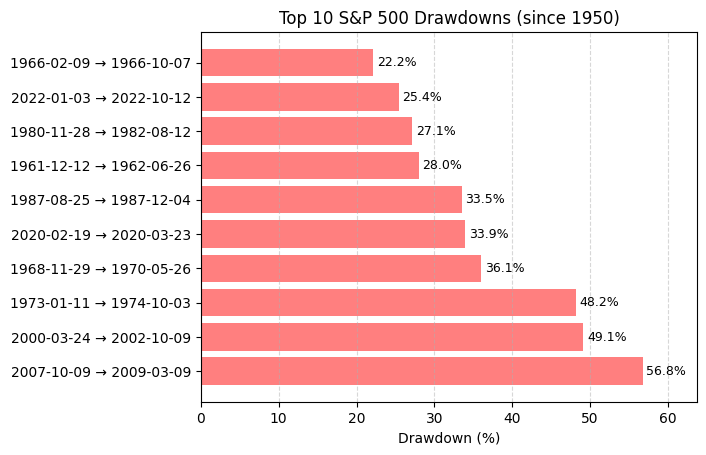

In [ ]:
# top_drawdowns = ath_dips_df.sort_values('Drawdown_%', ascending=False).head(10)

# plt.figure(figsize=(10, 6))
plt.barh(
    [f"{row.from_date.date()} → {row.to_date.date()}" for row in top_drawdowns.itertuples()],
    top_drawdowns['drawdown%'],
    color='#FF7F7F'
)

# Добавление текста справа от каждой полоски
for i, (value, label) in enumerate(zip(top_drawdowns['drawdown%'], top_drawdowns.itertuples())):
    plt.text(
        value + 0.5,  # немного правее конца бара
        i,            # позиция по y
        f"{value:.1f}%",  # форматированный текст (например, 23.4%)
        va='center',
        fontsize=9
    )

plt.title("Top 10 S&P 500 Drawdowns (since 1950)")
plt.xlabel("Drawdown (%)")
# plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, top_drawdowns['drawdown%'].max() + 7)  # немного больше максимума

plt.show()

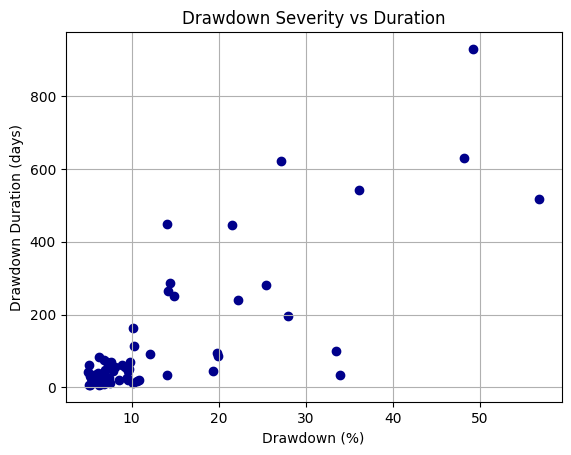

In [ ]:
plt.scatter( corrections['drawdown%'], corrections['durations_days'], color='darkblue')
plt.ylabel("Drawdown Duration (days)")
plt.xlabel("Drawdown (%)")
plt.title("Drawdown Severity vs Duration")
plt.grid(True)
plt.show()

In [ ]:
percentiles

{0.25: 21.5, 0.5: 39.0, 0.75: 89.0}

In [ ]:
print(f"The median is {percentiles[0.5]}")

The median is 39.0


---
### Question 4: [Strategy] Simple RSI-Based Trading Strategy


**What is the total profit (in $thousands) you would have earned by investing $1000 every time a stock was oversold (RSI < 25)?**


---

#### Goal:
Apply a simple rule-based trading strategy using the **Relative Strength Index (RSI)** technical indicator to identify oversold signals and calculate profits.

---


#### Steps:

1. **Run the full notebook from Lecture 2 (33 stocks)**  
   - Ensure you can generate the merged DataFrame containing:  
     - OHLCV data  
     - Technical indicators  
     - Macro indicators  
   - Focus on getting **RSI** computed using **Code Snippets 8 and 9**.  
   - This process is essential and will help during the capstone project.

2. ⚠️ **IMPORTANT** Please use this file to solve the Home Assignment (**all next steps**)

   Download precomputed data using this snippet:

   ```python
   import gdown
   import pandas as pd

   file_id = "1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-"
   gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.parquet", quiet=False)
   df = pd.read_parquet("data.parquet", engine="pyarrow")

3. **RSI Strategy Setup:**  
   - RSI is already available in the dataset as a field.  
   - The threshold for **oversold** is defined as `RSI < 25`.

4. **Filter the dataset by RSI and date:**  
   ```python
   rsi_threshold = 25
   selected_df = df[
       (df['rsi'] < rsi_threshold) &
       (df['Date'] >= '2000-01-01') &
       (df['Date'] <= '2025-06-01')
   ]
5. **Calculate Net Profit Over 25 Years:**  
   - Total number of trades: **1568**  
   - For each trade, you invest **$1000**  
   - Use the 30-day forward return (`growth_future_30d`) to compute net earnings:  
     ```python
     net_income = 1000 * (selected_df['growth_future_30d'] - 1).sum()
     ```

   - **Final Answer:**  
     What is the **net income in $K** (i.e., in thousands of dollars) that could be earned using this RSI-based oversold strategy from 2000–2025?


In [ ]:
AMZN_df = pd.read_csv("ha1_Amazon.csv", delimiter=';').dropna(subset=["Earnings Date"])

In [ ]:
AMZN_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 116 entries, 0 to 115
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Symbol         116 non-null    object
 1   Company        116 non-null    object
 2   Earnings Date  116 non-null    object
 3   EPS Estimate   116 non-null    object
 4   Reported EPS   116 non-null    object
 5   Surprise (%)   116 non-null    object
dtypes: object(6)
memory usage: 6.3+ KB


In [ ]:
# Преобразуем 'Surprise (%)' в число (float)
AMZN_df["Reported EPS"] = pd.to_numeric(AMZN_df["Reported EPS"], errors="coerce")
AMZN_df["EPS Estimate"] = pd.to_numeric(AMZN_df["EPS Estimate"], errors="coerce")
AMZN_df["Surprise (%)"] = pd.to_numeric(AMZN_df["Surprise (%)"], errors="coerce")

In [ ]:
# Преобразуем 'Earnings Date' в Timestamp
AMZN_df['Earnings Date'] = AMZN_df['Earnings Date'].str.replace(r"\s+at.*", "", regex=True)
AMZN_df['Earnings Date'] = pd.to_datetime(AMZN_df['Earnings Date'])

In [ ]:
AMZN_df.head(20)

,Symbol,Company,Earnings Date,EPS Estimate,Reported EPS,Surprise (%)
0,AMZN,Amazon.com Inc,2026-04-29,NaN,NaN,NaN
1,AMZN,Amazon.com Inc,2026-02-04,NaN,NaN,NaN
2,AMZN,Amazon.com Inc,2025-10-29,NaN,NaN,NaN
3,AMZN,Amazon.com Inc,2025-07-30,NaN,NaN,NaN
4,AMZN,"Amazon.com, Inc.",2025-05-01,1.36,1.59,16.74
5,AMZN,"Amazon.com, Inc.",2025-02-06,1.49,1.86,24.47
6,AMZN,"Amazon.com, Inc.",2024-10-31,1.14,1.43,25.17
7,AMZN,"Amazon.com, Inc.",2024-08-01,1.03,1.26,22.58
8,AMZN,"Amazon.com, Inc.",2024-04-30,0.83,0.98,17.91
9,AMZN,"Amazon.com, Inc.",2024-02-01,0.80,1.00,24.55


In [ ]:
# Step 2: Download Amazon historical price data
AMZN_hist = yf.Ticker("AMZN").history(start="1997-01-01", end="2025-05-01")["Close"]
AMZN_hist = AMZN_hist.reset_index()
AMZN_hist.columns = ["date", "close"]
# Step 3
AMZN_hist["close_day1"] = AMZN_hist["close"]
AMZN_hist["close_day3"] = AMZN_hist["close"].shift(-2)
AMZN_hist["2_day_return"] = (AMZN_hist["close_day3"] / AMZN_hist["close_day1"]) - 1

In [ ]:
AMZN_hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7034 entries, 0 to 7033
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype                           
---  ------        --------------  -----                           
 0   date          7034 non-null   datetime64[ns, America/New_York]
 1   close         7034 non-null   float64                         
 2   close_day1    7034 non-null   float64                         
 3   close_day3    7032 non-null   float64                         
 4   2_day_return  7032 non-null   float64                         
dtypes: datetime64[ns, America/New_York](1), float64(4)
memory usage: 274.9 KB


In [ ]:
filtered_df = AMZN_df[AMZN_df['Reported EPS'] > AMZN_df['EPS Estimate']]

filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37 entries, 4 to 81
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Symbol         37 non-null     object        
 1   Company        37 non-null     object        
 2   Earnings Date  37 non-null     datetime64[ns]
 3   EPS Estimate   37 non-null     float64       
 4   Reported EPS   37 non-null     float64       
 5   Surprise (%)   37 non-null     float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 2.0+ KB


In [ ]:
AMZN_hist['date'] = AMZN_hist['date'].dt.tz_localize(None)
amazon_positive = pd.merge(AMZN_hist,
                           filtered_df[["Earnings Date", "Surprise (%)"]],
                           left_on = 'date',
                           right_on='Earnings Date',
                           how='inner')
amazon_positive

,date,close,close_day1,close_day3,2_day_return,Earnings Date,Surprise (%)
0,2006-02-02,2.137000,2.137000,1.897500,-0.112073,2006-02-02,120.86
1,2008-07-23,3.527000,3.527000,3.915500,0.110150,2008-07-23,42.09
2,2009-01-29,2.500000,2.500000,3.057500,0.223000,2009-01-29,33.20
3,2010-10-21,8.248500,8.248500,8.450000,0.024429,2010-10-21,7.28
4,2011-01-27,9.222500,9.222500,8.482000,-0.080293,2011-01-27,3.03
5,2012-01-31,9.722000,9.722000,9.086000,-0.065419,2012-01-31,127.00
6,2015-01-29,15.589000,15.589000,18.223499,0.168997,2015-01-29,168.18
7,2015-07-23,24.108999,24.108999,26.570499,0.102099,2015-07-23,237.28
8,2015-10-22,28.195499,28.195499,30.430500,0.079268,2015-10-22,225.37
9,2016-04-28,30.100000,30.100000,34.192501,0.135963,2016-04-28,81.42


In [ ]:
amazon_positive['2_day_return'].mean().round(3)*100

np.float64(1.9)

In [ ]:
# Normalize data (divide by maximum Adj.Close for each stock)
normalized_data = (data - data.min(axis=0)) / data.max(axis=0)

# Round to two decimal places
normalized_data = normalized_data.round(2)

# Print the normalized data (showing the first 5 rows for each stock)
print(normalized_data.head(50))

Price      Adj Close                   Close                    High        \
Ticker          AAPL  GOOG   JPM  MSFT  AAPL  GOOG   JPM  MSFT  AAPL  GOOG   
Date                                                                         
2023-01-03      0.00  0.02  0.05  0.04  0.00  0.02  0.06  0.05  0.02  0.02   
2023-01-04      0.01  0.01  0.06  0.02  0.01  0.01  0.07  0.02  0.00  0.02   
2023-01-05      0.00  0.00  0.06  0.00  0.00  0.00  0.06  0.00  0.00  0.00   
2023-01-06      0.02  0.01  0.07  0.01  0.02  0.01  0.08  0.01  0.01  0.00   
2023-01-09      0.03  0.01  0.07  0.01  0.03  0.01  0.07  0.01  0.03  0.02   
2023-01-10      0.03  0.02  0.08  0.02  0.03  0.02  0.08  0.02  0.02  0.01   
2023-01-11      0.04  0.04  0.08  0.03  0.04  0.04  0.09  0.04  0.03  0.03   
2023-01-12      0.04  0.04  0.08  0.04  0.04  0.04  0.09  0.04  0.03  0.03   
2023-01-13      0.05  0.04  0.10  0.04  0.05  0.04  0.11  0.04  0.04  0.03   
2023-01-17      0.05  0.04  0.09  0.05  0.06  0.04  0.09  0.05  

In [ ]:
# Calculate 52-week range for each stock
fifty_two_week_ranges = (data.max() - data.min()) / data.min()
# Find the stock with the highest 52-week range
highest_range_stock = fifty_two_week_ranges.idxmax()
highest_range_value = fifty_two_week_ranges.max()

# Print the result
print(f"Акція з найвищим 52-тижневим діапазоном у 2023 році - це {highest_range_stock} з співвідношенням діапазону {highest_range_value:.2f}")

Акція з найвищим 52-тижневим діапазоном у 2023 році - це ('Volume', '2222.SR') з співвідношенням діапазону inf


### Q5. [Ознайомче, необов'язкове] Прогнозування IPO з позитивною прибутковістю

Більшість стратегій інвестування в ІРО дають **від'ємну середню та медіанну доходність** (і навіть 75% квантилів).

**Запитання:**
Як би ви змінили стратегію, якби хотіли **збільшити прибутковість**?

> Це питання для мозкового штурму з відкритою відповіддю - пропонуйте ідеї щодо визначення IPO з позитивною майбутньою прибутковістю або побудови більш ефективної торгової стратегії.

In [ ]:
# INDEXES from Yahoo Finance
# DAX index (XETRA - XETRA Delayed Price. Currency in EUR)
# WEB: https://finance.yahoo.com/quote/%5EGDAXI
dax_daily = yf.download(tickers = "^GDAXI",
                     period = "max",
                     interval = "1d")

[*********************100%%**********************]  1 of 1 completed


In [ ]:
dax_daily.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-04-15,17937.619141,18191.949219,17937.619141,18026.580078,18026.580078,65138500
2024-04-16,18022.169922,18022.689453,17713.500000,17766.230469,17766.230469,73217300
2024-04-17,17764.029297,17907.580078,17731.789062,17770.019531,17770.019531,55970700
2024-04-18,17775.410156,17863.320312,17716.919922,17837.400391,17837.400391,60700500
2024-04-19,17834.830078,17834.869141,17626.900391,17737.359375,17737.359375,79447700


In [ ]:
# normally 252 trading days
dax_daily['adj_close_last_year'] = dax_daily['Adj Close'].shift(252)
dax_daily['yoy_growth'] = dax_daily['Adj Close'] / dax_daily['adj_close_last_year'] -1

In [ ]:
dax_daily

,Open,High,Low,Close,Adj Close,Volume,adj_close_last_year,yoy_growth
Date,,,,,,,,
1987-12-30,1005.190002,1005.190002,1005.190002,1005.190002,1005.190002,0,NaN,NaN
1988-01-04,956.489990,956.489990,956.489990,956.489990,956.489990,0,NaN,NaN
1988-01-05,996.099976,996.099976,996.099976,996.099976,996.099976,0,NaN,NaN
1988-01-06,1006.010010,1006.010010,1006.010010,1006.010010,1006.010010,0,NaN,NaN
1988-01-07,1014.469971,1014.469971,1014.469971,1014.469971,1014.469971,0,NaN,NaN
...,...,...,...,...,...,...,...,...
2024-04-15,17937.619141,18191.949219,17937.619141,18026.580078,18026.580078,65138500,15895.200195,0.134090
2024-04-16,18022.169922,18022.689453,17713.500000,17766.230469,17766.230469,73217300,15795.969727,0.124732
2024-04-17,17764.029297,17907.580078,17731.789062,17770.019531,17770.019531,55970700,15881.660156,0.118902


<Axes: xlabel='Date'>

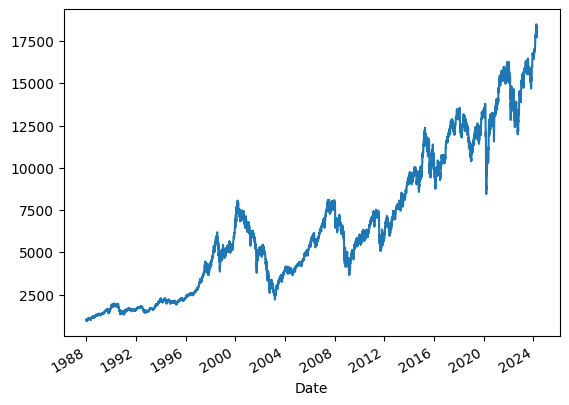

In [ ]:
dax_daily['Adj Close'].plot.line()

In [ ]:
# delayed 15 min : https://finance.yahoo.com/quote/%5ESPX/
# S&P 500 INDEX : Chicago Options - Chicago Options Delayed Price. Currency in USD
snp500_daily = yf.download(tickers = "^SPX",
                     period = "max",
                     interval = "1d")

[*********************100%%**********************]  1 of 1 completed


In [ ]:
snp500_daily.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-04-15,5149.669922,5168.430176,5052.470215,5061.819824,5061.819824,3950210000
2024-04-16,5064.589844,5079.839844,5039.830078,5051.410156,5051.410156,4006200000
2024-04-17,5068.970215,5077.959961,5007.250000,5022.209961,5022.209961,3596130000
2024-04-18,5031.520020,5056.660156,5001.890137,5011.120117,5011.120117,3619760000
2024-04-19,5005.439941,5019.020020,4953.560059,4967.229980,4967.229980,3878750000


In [ ]:
# https://finance.yahoo.com/quote/%5EGSPC/
# SNP - SNP Real Time Price. Currency in USD
snp500_daily_non_delayed = yf.download(tickers = "^GSPC",
                     period = "max",
                     interval = "1d")

[*********************100%%**********************]  1 of 1 completed


In [ ]:
snp500_daily_non_delayed.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-04-15,5149.669922,5168.430176,5052.470215,5061.819824,5061.819824,3950210000
2024-04-16,5064.589844,5079.839844,5039.830078,5051.410156,5051.410156,4006200000
2024-04-17,5068.970215,5077.959961,5007.250000,5022.209961,5022.209961,3596130000
2024-04-18,5031.520020,5056.660156,5001.890137,5011.120117,5011.120117,3619760000
2024-04-19,5005.439941,5019.020020,4953.560059,4967.229980,4967.229980,3878750000


In [ ]:
# Dow Jones Industrial Average: https://finance.yahoo.com/quote/%5EDJI?.tsrc=fin-srch
dji_daily = yf.download(tickers = "^DJI",
                     period = "max",
                     interval = "1d")

[*********************100%%**********************]  1 of 1 completed


## 2.2 OHLCV data daily - ETFs

In [ ]:
# https://finance.yahoo.com/quote/VOO?.tsrc=fin-srch
voo_etf = yf.download(tickers = "VOO",
                     period = "max",
                     interval = "1d")


[*********************100%%**********************]  1 of 1 completed


In [ ]:
voo_etf.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-04-15,473.470001,473.589996,462.850006,463.609985,463.609985,9530000
2024-04-16,464.049988,465.510010,461.589996,462.779999,462.779999,6761400
2024-04-17,465.109985,465.239990,458.730011,459.989990,459.989990,7156200
2024-04-18,461.359985,463.299988,458.209991,458.940002,458.940002,5637300
2024-04-19,458.989990,459.940002,453.899994,455.100006,455.100006,9766100


In [ ]:
# ETFs
# WisdomTree India Earnings Fund (EPI)
# NYSEArca - Nasdaq Real Time Price. Currency in USD
# WEB: https://finance.yahoo.com/quote/EPI/history?p=EPI
epi_etf_daily = yf.download(tickers = "EPI",
                     period = "max",
                     interval = "1d")

[*********************100%%**********************]  1 of 1 completed


In [ ]:
epi_etf_daily.head()
print(epi_etf_daily.shape)

(4066, 6)


In [ ]:
# find dividends impact on Close vs. Adj.Close
epi_etf_daily[(epi_etf_daily.index >='2023-06-23') & (epi_etf_daily.index <='2023-06-28')]

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-06-23,34.029999,34.150002,33.930000,34.020000,33.960003,344100
2023-06-26,34.110001,34.160000,34.049999,34.080002,34.080002,634600
2023-06-27,34.279999,34.310001,34.230000,34.310001,34.310001,417100
2023-06-28,34.410000,34.529999,34.389999,34.529999,34.529999,454400


In [ ]:
# find dividends - diff for Close vs. Adj Close
# Open/Close for 06-25 diff is close to divs = 1.845 (~1.58 for Open and 1.3 for Close)
# HELP: https://help.yahoo.com/kb/SLN28256.html#:~:text=Adjusted%20close%20is%20the%20closing,Security%20Prices%20(CRSP)%20standards.
epi_etf_daily[(epi_etf_daily.index >='2022-06-23') & (epi_etf_daily.index <='2022-06-28')]

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-06-23,31.129999,31.26,31.000000,31.200001,29.303230,607700
2022-06-24,29.549999,29.91,29.500000,29.900000,29.847267,387900
2022-06-27,29.799999,29.82,29.660000,29.709999,29.657600,225400
2022-06-28,29.709999,29.76,29.389999,29.420000,29.368114,466600


<Axes: title={'center': "EPI's etf stock price"}, xlabel='Date'>

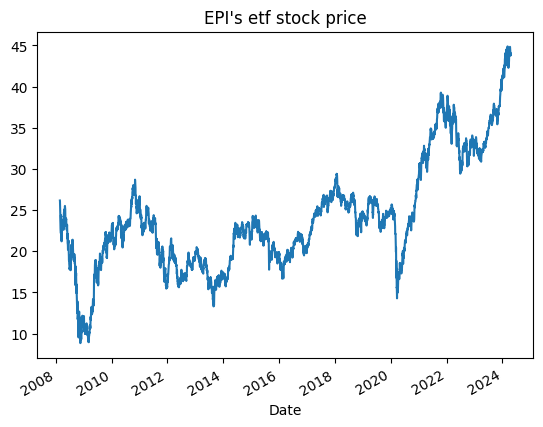

In [ ]:
# About yFinance: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html

epi_etf_daily['Close'].plot(title="EPI's etf stock price")

In [ ]:
# get actions, incl. dividends - as a dataFrame
epi = yf.Ticker('EPI')
epi.get_actions()

,Dividends,Stock Splits,Capital Gains
Date,,,
2008-12-22 00:00:00-05:00,0.091,0.0,0.0
2009-03-23 00:00:00-04:00,0.007,0.0,0.0
2009-06-22 00:00:00-04:00,0.002,0.0,0.0
2009-09-21 00:00:00-04:00,0.045,0.0,0.0
2009-12-21 00:00:00-05:00,0.006,0.0,0.0
2010-06-28 00:00:00-04:00,0.065,0.0,0.0
2010-09-20 00:00:00-04:00,0.065,0.0,0.0
2010-12-22 00:00:00-05:00,0.013,0.0,0.0
2011-06-22 00:00:00-04:00,0.062,0.0,0.0


In [ ]:
# get dividends as Series
epi.get_dividends()

Date
2008-12-22 00:00:00-05:00    0.091
2009-03-23 00:00:00-04:00    0.007
2009-06-22 00:00:00-04:00    0.002
2009-09-21 00:00:00-04:00    0.045
2009-12-21 00:00:00-05:00    0.006
2010-06-28 00:00:00-04:00    0.065
2010-09-20 00:00:00-04:00    0.065
2010-12-22 00:00:00-05:00    0.013
2011-06-22 00:00:00-04:00    0.062
2011-09-26 00:00:00-04:00    0.098
2012-03-26 00:00:00-04:00    0.010
2012-06-25 00:00:00-04:00    0.045
2012-09-24 00:00:00-04:00    0.083
2012-12-24 00:00:00-05:00    0.024
2013-06-24 00:00:00-04:00    0.068
2013-09-23 00:00:00-04:00    0.063
2014-03-24 00:00:00-04:00    0.099
2014-06-23 00:00:00-04:00    0.059
2014-09-22 00:00:00-04:00    0.068
2015-03-23 00:00:00-04:00    0.031
2015-06-22 00:00:00-04:00    0.067
2015-09-21 00:00:00-04:00    0.116
2015-12-21 00:00:00-05:00    0.024
2016-03-21 00:00:00-04:00    0.010
2016-06-20 00:00:00-04:00    0.125
2016-09-26 00:00:00-04:00    0.070
2016-12-23 00:00:00-05:00    0.006
2017-03-27 00:00:00-04:00    0.075
2017-06-26 00:0

## 2.3 Paid data - Poligon.io (news endpoint)

In [ ]:
# Please read the article (section "Polygon.io News API"): https://pythoninvest.com/long-read/chatgpt-api-for-financial-news-summarization

In [ ]:
# Endpoint: https://polygon.io/docs/stocks/get_v2_reference_news

## 2.4 Macroeconomics

* add some indicator examples

In [ ]:
# Gold reserves excl. gold for China
# https://fred.stlouisfed.org/series/TRESEGCNM052N

In [ ]:
gold_reserves = pdr.DataReader("TRESEGCNM052N", "fred", start=start)

<Axes: xlabel='DATE'>

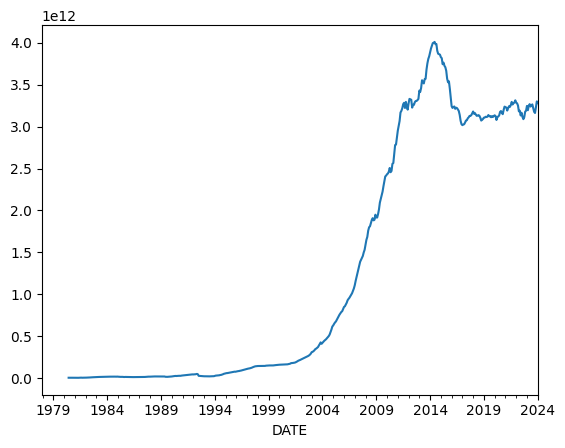

In [ ]:
gold_reserves.TRESEGCNM052N.plot.line()

In [ ]:
#  CBOE Gold ETF Volatility Index (GVZCLS)
# https://fred.stlouisfed.org/series/GVZCLS
gold_volatility = pdr.DataReader("GVZCLS", "fred", start=start)

<Axes: xlabel='DATE'>

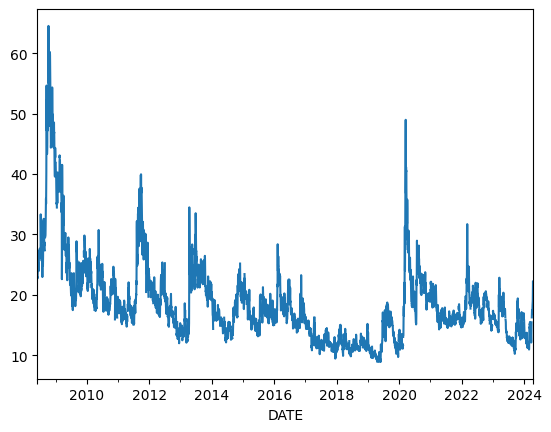

In [ ]:
gold_volatility.GVZCLS.plot.line()

In [ ]:
#  Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma (DCOILWTICO)
# https://fred.stlouisfed.org/series/DCOILWTICO
oil_wti = pdr.DataReader("DCOILWTICO", "fred", start=start)

<Axes: xlabel='DATE'>

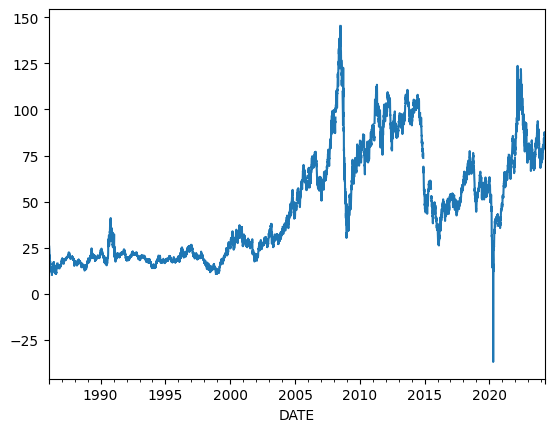

In [ ]:
# there is a bug in the data? negative price?
oil_wti.DCOILWTICO.plot.line()

In [ ]:
# Crude Oil Prices: Brent - Europe (DCOILBRENTEU)
# https://fred.stlouisfed.org/series/DCOILBRENTEU
oil_brent = pdr.DataReader("DCOILBRENTEU", "fred", start=start)

<Axes: xlabel='DATE'>

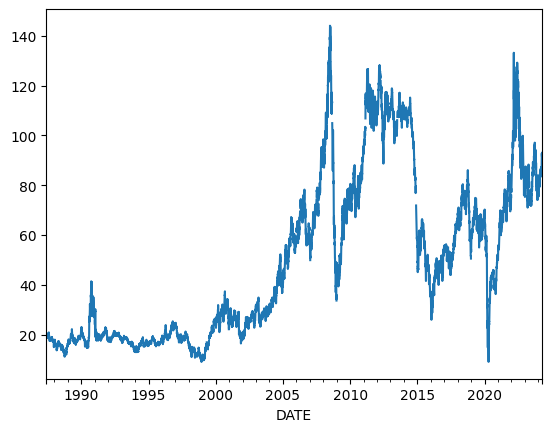

In [ ]:
oil_brent.DCOILBRENTEU.plot.line()

In [ ]:
# Web Scraping for Macro
# can't call directly via pd.read_html() as it returns 403 (forbidden) --> need to do a bit of work, but still no Selenium
# https://tradingeconomics.com/united-states/indicators
import requests
from bs4 import BeautifulSoup


url = "https://tradingeconomics.com/united-states/indicators"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

response = requests.get(url, headers=headers)

In [ ]:

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # You need to be able to find this table tag and read all behind it
    # Find the div with class "table-responsive"
    table_div = soup.find("div", class_="table-responsive")

    # Extract the table within the div
    table = table_div.find("table")

    # Use pandas to read the table into a DataFrame
    df = pd.read_html(str(table))[0]  # Assuming there's only one table, otherwise, loop through the list

    # Display the DataFrame
    print(df)
else:
    print("Failed to retrieve data from the webpage.")

                  Unnamed: 0    Last  Previous  Highest    Lowest  \
0                   Currency   106.0     106.0   165.00     70.70   
1               Stock Market  4967.0    5011.0  5268.00      4.40   
2            GDP Growth Rate     3.4       4.9    34.80    -28.00   
3     GDP Annual Growth Rate     3.1       2.9    13.40     -7.50   
4          Unemployment Rate     3.8       3.9    14.90      2.50   
5          Non Farm Payrolls   303.0     270.0  4615.00 -20477.00   
6             Inflation Rate     3.5       3.2    23.70    -15.80   
7         Inflation Rate MoM     0.4       0.4     2.00     -1.80   
8              Interest Rate     5.5       5.5    20.00      0.25   
9           Balance of Trade   -68.9     -67.6     1.95   -103.00   
10           Current Account  -195.0    -196.0     9.96   -284.00   
11    Current Account to GDP    -3.0      -3.8     0.20     -6.00   
12    Government Debt to GDP   129.0     127.0   129.00     31.80   
13         Government Budget    -5

C:\Users\bober\AppData\Local\Temp\ipykernel_13888\582078532.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]  # Assuming there's only one table, otherwise, loop through the list


In [ ]:
df

,Unnamed: 0,Last,Previous,Highest,Lowest,Unnamed: 5,Unnamed: 6
0,Currency,106.0,106.0,165.00,70.70,NaN,Apr/24
1,Stock Market,4967.0,5011.0,5268.00,4.40,points,Apr/24
2,GDP Growth Rate,3.4,4.9,34.80,-28.00,percent,Dec/23
3,GDP Annual Growth Rate,3.1,2.9,13.40,-7.50,percent,Dec/23
4,Unemployment Rate,3.8,3.9,14.90,2.50,percent,Mar/24
5,Non Farm Payrolls,303.0,270.0,4615.00,-20477.00,Thousand,Mar/24
6,Inflation Rate,3.5,3.2,23.70,-15.80,percent,Mar/24
7,Inflation Rate MoM,0.4,0.4,2.00,-1.80,percent,Mar/24
8,Interest Rate,5.5,5.5,20.00,0.25,percent,Mar/24
9,Balance of Trade,-68.9,-67.6,1.95,-103.00,USD Billion,Feb/24


### Question 5.  [Exploratory, optional] Мозковий штурм потенційних ідей для вашого завершального проекту

**Free text answer**

Опишіть проект, який ви хотіли б реалізувати, враховуючи ваші прагнення, прогнози ML-моделі та попередні знання. Навіть якщо ви не впевнені на цьому етапі, спробуйте сформулювати ідею, яку ви хотіли б дослідити - наприклад, конкретний клас активів, країна, галузева вертикаль або інвестиційна стратегія. Будьте максимально конкретними.

*Example: Я хочу побудувати модель короткострокового прогнозування для фондових ринків США/Індії/Бразилії, зосередившись на найбільших акціях на 30-денному інвестиційному горизонті. Я планую використовувати технічні індикатори RSI та MACD, а також дані про випуски новин для створення прогнозів.*


In [ ]:
import yfinance as yf

# Define the list of symbols
symbols = [ "AAPL", "MSFT", "GOOG", "JPM"]

# Create a dictionary to store dividend yields for each symbol
dividend_yields = {}

for symbol in symbols:
    # Get stock information using Ticker object
    stock_data = yf.Ticker(symbol)

    # Check if dividends data is available (handle potential exceptions)
    try:
        # Access dividends data directly from the info dictionary
        dividends = stock_data.dividends
        print(dividends)
    except KeyError:
        # Handle case where dividends data is not available
        print(f"Dividends data not found for {symbol}. Skipping...")
        dividends = []  # Empty list to avoid errors in calculations

#     # Filter and calculate total dividends paid in 2023
#     filtered_dividends = [d for d in dividends if int(d['Date'].year) == 2023]
#     total_dividends = sum(d['amount'] for d in filtered_dividends)
#
#     # Get last closing price (Adj.Close) for 2023
#     last_close_price = stock_data.history(period="1d", end="2023-12-31")["Adj Close"].iloc[-1]
#
#     # Calculate dividend yield (handle potential division by zero)
#     if last_close_price > 0:
#         dividend_yield = (total_dividends / last_close_price) * 100
#         dividend_yield = round(dividend_yield, 1)
#     else:
#         dividend_yield = 0.0  # Set to zero for zero or negative closing price
#
#     # Store dividend yield for the symbol
#     dividend_yields[symbol] = dividend_yield
#
# # Find the stock with the highest dividend yield
# highest_dividend_yield = max(dividend_yields.values())
# highest_dividend_yield_symbol = max(dividend_yields, key=dividend_yields.get)
#
# # Print the result
# print(f"Акція з найвищою дивідендною прибутковістю у 2023 році: {highest_dividend_yield_symbol} з дивідендною прибутковістю {highest_dividend_yield}%")


Date
1987-05-11 00:00:00-04:00    0.000536
1987-08-10 00:00:00-04:00    0.000536
1987-11-17 00:00:00-05:00    0.000714
1988-02-12 00:00:00-05:00    0.000714
1988-05-16 00:00:00-04:00    0.000714
                               ...   
2023-02-10 00:00:00-05:00    0.230000
2023-05-12 00:00:00-04:00    0.240000
2023-08-11 00:00:00-04:00    0.240000
2023-11-10 00:00:00-05:00    0.240000
2024-02-09 00:00:00-05:00    0.240000
Name: Dividends, Length: 82, dtype: float64
Date
2003-02-19 00:00:00-05:00    0.08
2003-10-15 00:00:00-04:00    0.16
2004-08-23 00:00:00-04:00    0.08
2004-11-15 00:00:00-05:00    3.08
2005-02-15 00:00:00-05:00    0.08
                             ... 
2023-02-15 00:00:00-05:00    0.68
2023-05-17 00:00:00-04:00    0.68
2023-08-16 00:00:00-04:00    0.68
2023-11-15 00:00:00-05:00    0.75
2024-02-14 00:00:00-05:00    0.75
Name: Dividends, Length: 81, dtype: float64
Series([], Name: Dividends, dtype: float64)
Date
1984-03-09 00:00:00-05:00    0.196667
1984-06-11 00:00:00-04:

## 2.5) Financial reporting - EDGAR (in Yahoo)

In [ ]:
# let's check for NVDA
nvda =  yf.Ticker('NVDA')

In [ ]:
# yearly financials for the last 4 years
nvda.financials


,2024-01-31,2023-01-31,2022-01-31,2021-01-31
Tax Effect Of Unusual Items,0.0,-284130000.0,0.0,0.0
Tax Rate For Calcs,0.12,0.21,0.019,0.017
Normalized EBITDA,35583000000.0,7340000000.0,11351000000.0,5691000000.0
Total Unusual Items,0.0,-1353000000.0,0.0,0.0
Total Unusual Items Excluding Goodwill,0.0,-1353000000.0,0.0,0.0
Net Income From Continuing Operation Net Minority Interest,29760000000.0,4368000000.0,9752000000.0,4332000000.0
Reconciled Depreciation,1508000000.0,1544000000.0,1174000000.0,1098000000.0
Reconciled Cost Of Revenue,16621000000.0,11618000000.0,9439000000.0,6279000000.0
EBITDA,35583000000.0,5987000000.0,11351000000.0,5691000000.0
EBIT,34075000000.0,4443000000.0,10177000000.0,4593000000.0


In [ ]:
# balance sheet
nvda.balance_sheet

,2024-01-31,2023-01-31,2022-01-31,2021-01-31
Treasury Shares Number,NaN,NaN,NaN,1380000000.0
Ordinary Shares Number,2464000000.0,2466136572.0,2506000000.0,2480000000.0
Share Issued,2464000000.0,2466136572.0,2506000000.0,3860000000.0
Net Debt,2429000000.0,7564000000.0,8956000000.0,6116000000.0
Total Debt,11056000000.0,12031000000.0,11831000000.0,7597000000.0
...,...,...,...,...
Allowance For Doubtful Accounts Receivable,NaN,NaN,NaN,-21000000.0
Gross Accounts Receivable,NaN,NaN,NaN,2450000000.0
Cash Cash Equivalents And Short Term Investments,25984000000.0,13296000000.0,21208000000.0,11561000000.0
Other Short Term Investments,18704000000.0,9907000000.0,19218000000.0,10714000000.0


In [ ]:
# Basic info:
nvda.basic_info

lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [ ]:
# marketCap is quite useful, but don't know when it was updated? Daily?
nvda.basic_info['marketCap']/1e9

1905.0

In [ ]:
# read this article for full info: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html

## 2.6 Web Scraping - company info for clustering

In [ ]:
# ask chatGPT: emulate clicking the link and downloading the content
import requests
from bs4 import BeautifulSoup

# URL of the webpage
url = "https://companiesmarketcap.com/"

# Define headers with a user-agent to mimic a web browser
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

# Send a GET request to the URL with headers
response = requests.get(url, headers=headers)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # Find the download link within the webpage
    download_link = soup.find("a", {"rel": "nofollow", "href": "?download=csv"})

    # If the download link is found
    if download_link:
        # Extract the href attribute which contains the actual download link
        download_url = 'https://companiesmarketcap.com/'+download_link["href"]

        # Download the CSV file using the obtained download URL
        download_response = requests.get(download_url, headers=headers)

        # Check if the download request was successful
        if download_response.status_code == 200:
            # Save the content of the response to a local file
            with open("global_stocks.csv", "wb") as f:
                f.write(download_response.content)
            print("CSV file downloaded successfully.")
        else:
            print("Failed to download the CSV file.")
    else:
        print("Download link not found on the webpage.")
else:
    print("Failed to retrieve data from the webpage.")

CSV file downloaded successfully.


In [ ]:
%%bash
ls

DGS10.csv
DGS2.csv
GDPC1.csv
^MXX.csv
global_stocks.csv
hw-01-ua.md
hw-01.ipynb


In [ ]:
global_stocks = pd.read_csv("./global_stocks.csv")

In [ ]:
global_stocks.head()

,Rank,Name,Symbol,marketcap,price (USD),country
0,1,Microsoft,MSFT,2965637169152,399.12,United States
1,2,Apple,AAPL,2547913326592,165.00,United States
2,3,Saudi Aramco,2222.SR,1929615470342,7.98,Saudi Arabia
3,4,Alphabet (Google),GOOG,1926240796672,155.72,United States
4,5,NVIDIA,NVDA,1905000054784,762.00,United States


In [ ]:
global_stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8386 entries, 0 to 8385
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Rank         8386 non-null   int64  
 1   Name         8386 non-null   object 
 2   Symbol       8385 non-null   object 
 3   marketcap    8386 non-null   int64  
 4   price (USD)  8386 non-null   float64
 5   country      8384 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 393.2+ KB
